Step 1: Setup


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fact    = pd.read_csv('E:/Swiggy/fact_orders.csv')
dim_date     = pd.read_csv('E:/Swiggy/dim_date.csv')
dim_dish     = pd.read_csv('E:/Swiggy/dim_dish.csv')
dim_location = pd.read_csv('E:/Swiggy/dim_location.csv')
dim_restaurant = pd.read_csv('E:/Swiggy/dim_restaurant.csv')

Step 2: Data Validation 

In [6]:
# 1. Shape and dtypes
print(fact.shape)
print(fact.dtypes)


(197430, 8)
order_id           int64
date_id            int64
location_id        int64
restaurant_id      int64
food_id            int64
price            float64
rating           float64
rating_count       int64
dtype: object


In [7]:
print(dim_date.shape)
print(dim_dish.dtypes)


(243, 2)
dish_id       int64
category     object
dish_name    object
dtype: object


In [8]:
print(dim_dish.shape)
print(dim_dish.dtypes)

(82891, 3)
dish_id       int64
category     object
dish_name    object
dtype: object


In [9]:
print(dim_location.shape)
print(dim_location.dtypes)

(995, 4)
location_id     int64
state          object
city           object
location       object
dtype: object


In [10]:
print(dim_restaurant.shape)
print(dim_restaurant.dtypes)

(993, 2)
restaurant_id       int64
restaurant_name    object
dtype: object


In [13]:
print(fact)

        order_id  date_id  location_id  restaurant_id  food_id  price  rating  \
0              1        1            1              1        1  133.9     4.0   
1              2        2            2              2        2   52.0     4.5   
2              3        3            2              2        3  117.0     4.7   
3              4        4            2              2        4   65.0     4.6   
4              5        5            2              2        5  130.0     4.0   
...          ...      ...          ...            ...      ...    ...     ...   
197425    197426      190          989            993    82887  112.0     4.4   
197426    197427      156          989            993    82888  140.0     4.4   
197427    197428       57          989            993    82889  126.0     4.4   
197428    197429      231          989            993    82890   85.0     4.4   
197429    197430      242          989            993    82891  100.0     4.4   

        rating_count  
0   

In [14]:
print(dim_date)

     date_id  order_date
0          1  2025-06-29
1          2  2025-04-03
2          3  2025-01-15
3          4  2025-04-17
4          5  2025-03-13
..       ...         ...
238      239  2025-03-07
239      240  2025-03-21
240      241  2025-03-02
241      242  2025-03-27
242      243  2025-03-08

[243 rows x 2 columns]


In [15]:
print(dim_dish)

       dish_id     category                dish_name
0            1        Snack      Butter Murukku200gm
1            2  Recommended               Badam Milk
2            3  Recommended           Chow Chow Bath
3            4  Recommended              Kesari Bath
4            5  Recommended               Mix Raitha
...        ...          ...                      ...
82886    82887        Momos  Soya cheese chilli momo
82887    82888        Momos       Kurkure momo fried
82888    82889        Momos       Chilli cheese momo
82889    82890        Momos           Veg Momos 8 Pc
82890    82891        Momos                Soya Momo

[82891 rows x 3 columns]


In [16]:
print(dim_location)

     location_id      state       city                location
0              1  Karnataka  Bengaluru    Rajarajeshwari Nagar
1              2  Karnataka  Bengaluru                 Kengeri
2              3  Karnataka  Bengaluru       Kanmanike Village
3              4  Karnataka  Bengaluru                  Bidadi
4              5  Karnataka  Bengaluru  Kengeri Satellite Town
..           ...        ...        ...                     ...
990          991     Sikkim    Gangtok               Gairigaon
991          992     Sikkim    Gangtok              West Point
992          993     Sikkim    Gangtok             Baluwakhani
993          994     Sikkim    Gangtok          Sikkim Manipal
994          995     Sikkim    Gangtok          DISTRICT COURT

[995 rows x 4 columns]


In [17]:
print(dim_restaurant)

     restaurant_id             restaurant_name
0                1    Anand Sweets & Savouries
1                2       Srinidhi Sagar Deluxe
2                3       Thalassery Restaurant
3                4  Appu Donne Biriyani Palace
4                5         Bismillah Taj Hotel
..             ...                         ...
988            989                Valley Vista
989            990                  Etho Metho
990            991                 Roll Corner
991            992         Hot Stuff Fast Food
992            993              Mama's Kitchen

[993 rows x 2 columns]


In [18]:
# 2. Null check
print(fact.isnull().sum())

order_id         0
date_id          0
location_id      0
restaurant_id    0
food_id          0
price            0
rating           0
rating_count     0
dtype: int64


In [19]:
print(dim_date.isnull().sum())

date_id       0
order_date    0
dtype: int64


In [20]:
print(dim_dish.isnull().sum())

dish_id      0
category     0
dish_name    0
dtype: int64


In [21]:
print(dim_location.isnull().sum())

location_id    0
state          0
city           0
location       0
dtype: int64


In [22]:
print(dim_restaurant.isnull().sum())

restaurant_id      0
restaurant_name    0
dtype: int64


In [23]:
# 3. Duplicate check
print(fact.duplicated().sum())
print(dim_date.duplicated().sum())
print(dim_dish.duplicated().sum())  
print(dim_location.duplicated().sum())
print(dim_restaurant.duplicated().sum())

0
0
0
0
0


In [24]:
# 4. Range validation
print(fact['price'].describe())         # min should not be 0 or negative
print(fact['rating'].describe())        # must be 1.5 to 5.0
print(fact['rating_count'].describe())  # must be >= 0


count    197430.000000
mean        268.512920
std         219.338363
min           0.950000
25%         139.000000
50%         229.000000
75%         329.000000
max        8000.000000
Name: price, dtype: float64
count    197430.000000
mean          4.341582
std           0.422585
min           1.500000
25%           4.300000
50%           4.400000
75%           4.500000
max           5.000000
Name: rating, dtype: float64
count    197430.000000
mean         28.321805
std          87.542593
min           0.000000
25%           0.000000
50%           2.000000
75%          15.000000
max         999.000000
Name: rating_count, dtype: float64


In [25]:
# 5. Referential integrity — do all FK IDs exist in their dimension?
assert fact['date_id'].isin(dim_date['date_id']).all(), "Orphan date_ids found"
assert fact['location_id'].isin(dim_location['location_id']).all(), "Orphan location_ids"
assert fact['restaurant_id'].isin(dim_restaurant['restaurant_id']).all(), "Orphan restaurant_ids"
assert fact['food_id'].isin(dim_dish['dish_id']).all(), "Orphan food_ids"

Step 3: Feature Engineering

In [26]:
# Parse date properly
dim_date['order_date'] = pd.to_datetime(dim_date['order_date'])
dim_date['month']      = dim_date['order_date'].dt.month
dim_date['month_name'] = dim_date['order_date'].dt.strftime('%b')
dim_date['year']       = dim_date['order_date'].dt.year
dim_date['day_of_week']= dim_date['order_date'].dt.day_name()
dim_date['quarter']    = dim_date['order_date'].dt.quarter

In [28]:
dim_date

,date_id,order_date,month,month_name,year,day_of_week,quarter
0,1,2025-06-29,6,Jun,2025,Sunday,2
1,2,2025-04-03,4,Apr,2025,Thursday,2
2,3,2025-01-15,1,Jan,2025,Wednesday,1
3,4,2025-04-17,4,Apr,2025,Thursday,2
4,5,2025-03-13,3,Mar,2025,Thursday,1
...,...,...,...,...,...,...,...
238,239,2025-03-07,3,Mar,2025,Friday,1
239,240,2025-03-21,3,Mar,2025,Friday,1
240,241,2025-03-02,3,Mar,2025,Sunday,1
241,242,2025-03-27,3,Mar,2025,Thursday,1


In [29]:
# Price tier segmentation
p75 = fact['price'].quantile(0.75)
fact['price_tier'] = pd.cut(
    fact['price'],
    bins=[0, 100, 200, p75, fact['price'].max()],
    labels=['Budget', 'Mid', 'Standard', 'Premium']
)

In [30]:
fact

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,price_tier
0,1,1,1,1,1,133.9,4.0,0,Mid
1,2,2,2,2,2,52.0,4.5,25,Budget
2,3,3,2,2,3,117.0,4.7,48,Mid
3,4,4,2,2,4,65.0,4.6,65,Budget
4,5,5,2,2,5,130.0,4.0,0,Mid
...,...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0,Mid
197426,197427,156,989,993,82888,140.0,4.4,0,Mid
197427,197428,57,989,993,82889,126.0,4.4,0,Mid
197428,197429,231,989,993,82890,85.0,4.4,0,Budget


In [31]:
# Flag: high price + low rating (KPI 7)
fact['is_anomaly'] = (fact['price'] > p75) & (fact['rating'] < 3.5)

In [32]:
fact

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,price_tier,is_anomaly
0,1,1,1,1,1,133.9,4.0,0,Mid,False
1,2,2,2,2,2,52.0,4.5,25,Budget,False
2,3,3,2,2,3,117.0,4.7,48,Mid,False
3,4,4,2,2,4,65.0,4.6,65,Budget,False
4,5,5,2,2,5,130.0,4.0,0,Mid,False
...,...,...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0,Mid,False
197426,197427,156,989,993,82888,140.0,4.4,0,Mid,False
197427,197428,57,989,993,82889,126.0,4.4,0,Mid,False
197428,197429,231,989,993,82890,85.0,4.4,0,Budget,False


In [33]:
# Flag: zero review
fact['is_zero_review'] = fact['rating_count'] == 0

In [34]:
fact

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,price_tier,is_anomaly,is_zero_review
0,1,1,1,1,1,133.9,4.0,0,Mid,False,True
1,2,2,2,2,2,52.0,4.5,25,Budget,False,False
2,3,3,2,2,3,117.0,4.7,48,Mid,False,False
3,4,4,2,2,4,65.0,4.6,65,Budget,False,False
4,5,5,2,2,5,130.0,4.0,0,Mid,False,True
...,...,...,...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0,Mid,False,True
197426,197427,156,989,993,82888,140.0,4.4,0,Mid,False,True
197427,197428,57,989,993,82889,126.0,4.4,0,Mid,False,True
197428,197429,231,989,993,82890,85.0,4.4,0,Budget,False,True


Step 4: EDA Visualisations

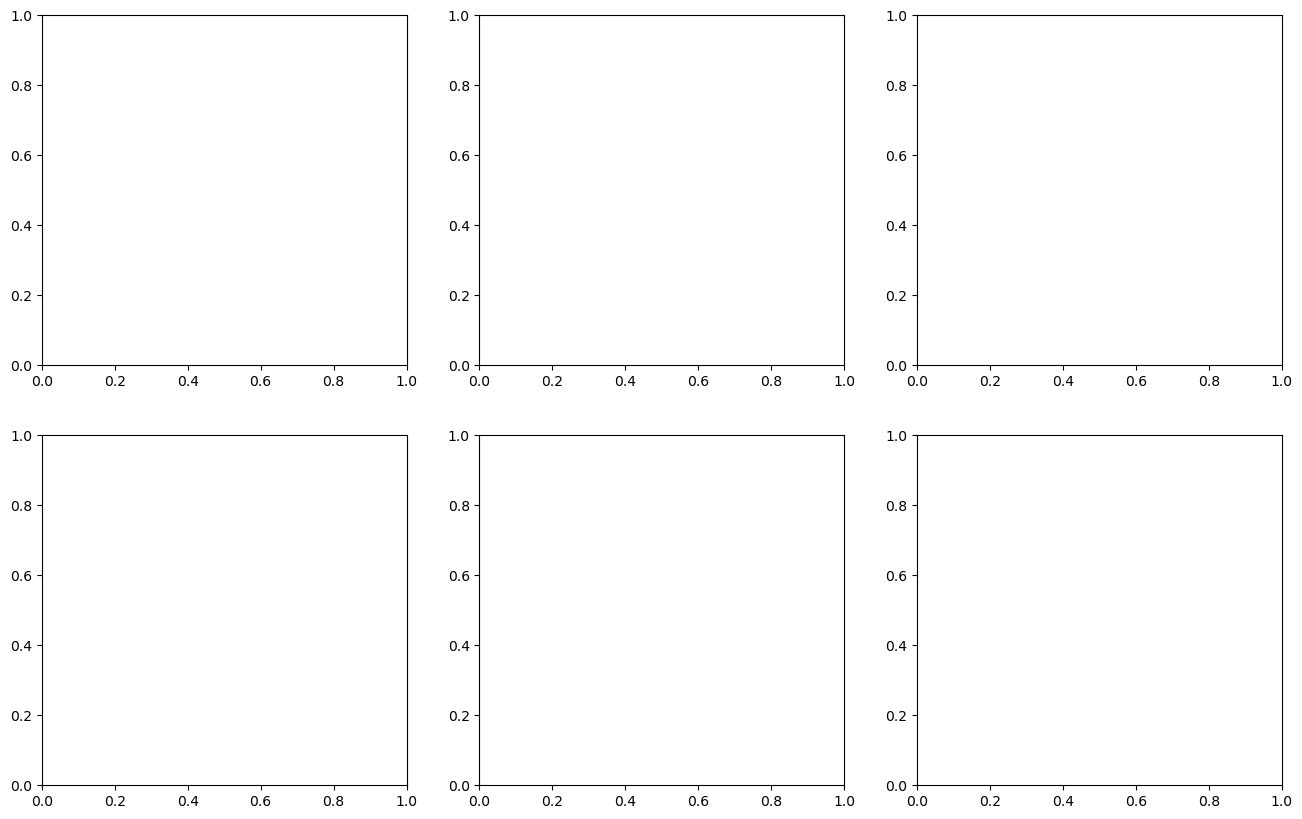

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

In [36]:
# 1. Price distribution
sns.histplot(fact['price'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (₹)')

Text(0.5, 424.44444444444446, 'Price (₹)')

In [37]:
# 2. Rating distribution
sns.histplot(fact['rating'], bins=20, ax=axes[0,1], color='coral')
axes[0,1].set_title('Rating Distribution')


Text(0.5, 1.0, 'Rating Distribution')

In [38]:
# 3. Orders per month (after joining dim_date)
merged = fact.merge(dim_date, on='date_id')
monthly = merged.groupby('month_name')['order_id'].count().reset_index()
sns.barplot(data=monthly, x='month_name', y='order_id', ax=axes[0,2], palette='Blues_d')
axes[0,2].set_title('Orders by Month')

C:\Users\91637\AppData\Local\Temp\ipykernel_25504\1452209631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='month_name', y='order_id', ax=axes[0,2], palette='Blues_d')


Text(0.5, 1.0, 'Orders by Month')

In [39]:
# 4. Price vs Rating scatter
sample = fact.sample(5000)
axes[1,0].scatter(sample['rating'], sample['price'], alpha=0.3, s=10)
axes[1,0].set_title('Price vs Rating')

Text(0.5, 1.0, 'Price vs Rating')

In [40]:
# 5. Top 10 dish categories by order count
cat_counts = fact.merge(dim_dish, left_on='food_id', right_on='dish_id')
top_cats = cat_counts['category'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1,1], palette='Greens_d')
axes[1,1].set_title('Top 10 Categories by Orders')

C:\Users\91637\AppData\Local\Temp\ipykernel_25504\3973174696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1,1], palette='Greens_d')


Text(0.5, 1.0, 'Top 10 Categories by Orders')

In [41]:
# 6. Orders per state
loc_fact = fact.merge(dim_location, on='location_id')
state_orders = loc_fact.groupby('state')['order_id'].count().sort_values(ascending=False).head(15)
sns.barplot(x=state_orders.values, y=state_orders.index, ax=axes[1,2], palette='Purples_d')
axes[1,2].set_title('Orders by State (Top 15)')

C:\Users\91637\AppData\Local\Temp\ipykernel_25504\1139640225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_orders.values, y=state_orders.index, ax=axes[1,2], palette='Purples_d')


Text(0.5, 1.0, 'Orders by State (Top 15)')

In [42]:
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Step 5: Export Clean Files

In [44]:
fact.to_csv('fact_orders_clean.csv', index=False)
dim_date.to_csv('dim_date_clean.csv', index=False)

In [45]:
fact

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count,price_tier,is_anomaly,is_zero_review
0,1,1,1,1,1,133.9,4.0,0,Mid,False,True
1,2,2,2,2,2,52.0,4.5,25,Budget,False,False
2,3,3,2,2,3,117.0,4.7,48,Mid,False,False
3,4,4,2,2,4,65.0,4.6,65,Budget,False,False
4,5,5,2,2,5,130.0,4.0,0,Mid,False,True
...,...,...,...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0,Mid,False,True
197426,197427,156,989,993,82888,140.0,4.4,0,Mid,False,True
197427,197428,57,989,993,82889,126.0,4.4,0,Mid,False,True
197428,197429,231,989,993,82890,85.0,4.4,0,Budget,False,True
